### note
<br/>

### note name

In [1]:
# pip install ipynbname

import ipynbname
nb_name = ipynbname.name()
nb_path = ipynbname.path()

nb_name

'2Samples Classical_LSTM_P406 SEEDs_ini_2'

## Hyper parameters

In [2]:
SEED = 2
# SEEDs = range(10) # 0~9
L_RATE = 0.2 # 0.2
N_STEPS = 1000000
NUM_SEEDs = 50

In [3]:
from jax.config import config
config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import pennylane as qml
from jax.example_libraries import optimizers
from jax.example_libraries import stax
from jax import value_and_grad
from jax import lax

import optax
# from functools import partial
import time
import matplotlib.pyplot as plt
import pickle


from SQGRU_j7x import SQGRU, qgru
from Classical_RNN import simple_rnn, gru, lstm, count_parameters

### force to use cpu

In [4]:
jax.config.update('jax_platform_name', 'cpu')

In [5]:
qml.version()

'0.31.1'

## Oscillations

In [6]:
def damped_shm(fre, damp):
    amp = 0.7
    num_data = 151
    x = jnp.array(range(num_data))
    y = jnp.sin(x*fre)*jnp.exp(x*damp)*amp

    return y

In [7]:
osc1 = damped_shm(0.4, 0)
osc2 = damped_shm(0.6, -0.02)

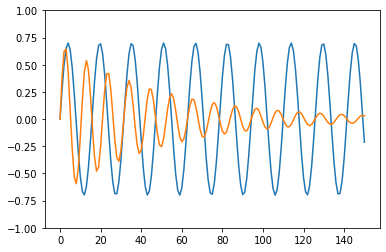

In [8]:
plt.plot(osc1)
plt.plot(osc2)
plt.ylim(-1,1)
plt.show()

In [9]:
oscillations = jnp.array([osc1,osc2])
true_data = jnp.expand_dims(oscillations, 2)
train_input = true_data[:,0:100,:]
train_target = true_data[:,1:101,:]

## Model
### Hyper parameters

In [10]:
# model parameters
OUT_DIM = 9

In [11]:
init_fun, qgru_rnn = stax.serial(lstm(OUT_DIM, sequence_out=True), stax.Dense(1))

In [12]:
key = jax.random.PRNGKey(SEED)
key1, key2 = jax.random.split(key, num=2)
_, params = init_fun(key1, jnp.shape(train_input))

In [13]:
count_parameters(params)

406

## Train

In [14]:
step_size = L_RATE
optimizer = optax.adam(step_size)
opt_state = optimizer.init(params)

In [15]:

@jax.jit
def loss_fn(params, xs, ys):
#     prediction = qgru_rnn(params, xs)[:,:,0:1]
    prediction = qgru_rnn(params, xs)
#     prediction = cls_predict(xs, 10, params)
    
    return jnp.mean((prediction - ys)**2) # the prediction shape


# def update(i_step, params, xs, ys, opt_state):
#     loss, grads = value_and_grad(loss_fn)(params, xs, ys)
#     updates, opt_state = optimizer.update(grads, opt_state)
#     params = optax.apply_updates(params, updates)
#     return params, opt_state, loss


In [16]:
minLoss = 1000
best_params = params
lossList = []
loc_params_list = []
reset_steps = []

In [17]:
def ck_lr(old_lr, new_lr):
    d_lr = old_lr - new_lr
    return d_lr >= 0 and d_lr/new_lr < 1e-2

### prediction

In [18]:
_, qgru_rnn2 = stax.serial(lstm(OUT_DIM, sequence_out=True), stax.Dense(1))

In [19]:
@jax.jit
def jit_rnn(params, inputs):
    return qgru_rnn2(params, inputs)

In [20]:
true1 = true_data.squeeze()[:,0:100]
true2 = true_data.squeeze()[:,100:]
xs = train_input

In [21]:
# for classical rnn to predict the trend
def cls_predict(inp, pred_length, params):
    ys = jit_rnn(params, inp)
    new_inp = inp
    for _ in range(pred_length-1):
        new_inp = jnp.concatenate([new_inp, ys[:,-1:]], axis=1)
        ys = jit_rnn(params, new_inp)
    return ys

### start

In [22]:
update_lr = True
lr_factor = 1
locLossList = [1000,1000,1000]
locLoss = 1000
loc_params = params



start = time.time()
for i in range(N_STEPS):
    
    if update_lr != 0:
        if update_lr < 0:
            params = loc_params
        else:
            locLossList = [1000,1000,1000]
            locLoss = 1000
            loc_params_list.append(loc_params)
            reset_steps.append(i)
            # reset parameters
            key1, key2 = jax.random.split(key2, num=2)
            _, params = init_fun(key1, jnp.shape(train_input))
            loc_params = params
            # stop when collect 3 local best parameters
            if len(loc_params_list) > NUM_SEEDs:
                break
        update_lr = 0
            
        # update learning rate
        optimizer = optax.adam(step_size)
        opt_state = optimizer.init(params)
        
        print('learning rate:', step_size)

        def update(i_step, params, xs, ys, opt_state):
            loss, grads = value_and_grad(loss_fn)(params, xs, ys)
            updates, opt_state = optimizer.update(grads, opt_state)
            params = optax.apply_updates(params, updates)
            return params, opt_state, loss
    
    pre_params = params
    params, opt_state, loss = update(i, params, train_input, train_target, opt_state)
    print('{}: {}   {} sec      '.format(i, loss, time.time()-start), end='\r')
    if loss < minLoss:
        best_params = pre_params
        minLoss = loss
    if loss < locLoss:
        loc_params = pre_params
        locLoss = loss
    if (i+1) % 100 == 0:
        # update learning rate?
        if loss > locLossList[0] and locLossList[1] > locLossList[0] and locLossList[2] > locLossList[0]:
            step_size /= 2
            update_lr = -1
        elif ck_lr(locLossList[2], loss) and ck_lr(locLossList[1], locLossList[2]) and ck_lr(locLossList[0], locLossList[1]):
            # reset
            step_size = L_RATE
            update_lr = 1
        locLossList[0] = locLossList[1]
        locLossList[1] = locLossList[2]
        locLossList[2] = loss
        
        
        lossList.append(loss)
        print('{}: {}   {} sec      '.format(i, loss, time.time()-start))

learning rate: 0.2
99: 0.00025650782691629174   1.7705190181732178 sec      
199: 0.00234746814697984   2.6241962909698486 sec         
299: 0.0001581157161668055   3.41274094581604 sec         
399: 0.00012612550776030585   4.219989776611328 sec       
499: 0.00041076092434526936   4.998112440109253 sec       
599: 9.428598952596491e-05   5.786174774169922 sec        
699: 0.00010441597523442862   6.559159517288208 sec       
799: 7.802115550814448e-05   7.341722726821899 sec        
899: 5.8717116136033143e-05   8.131554365158081 sec       
999: 6.800204364947901e-05   8.982587337493896 sec       
1099: 5.0126295728496434e-05   9.745677947998047 sec      
1199: 5.130394533837294e-05   10.496038913726807 sec       
1299: 5.73011018783979e-05   11.265611171722412 sec        
1399: 0.00044805181488600745   12.122366666793823 sec      
learning rate: 0.1
1499: 0.00015689516812633628   12.933493614196777 sec      
learning rate: 0.05
1599: 7.647027062488543e-05   13.748280763626099 sec   

26299: 3.541798941556782e-05   241.33196878433228 sec       
26399: 0.00018846433246477105   242.22558498382568 sec      
26499: 3.491417530874453e-05   243.09663486480713 sec       
26599: 3.442617104373891e-05   243.96705317497253 sec       
26699: 3.4799048817756176e-05   244.83041644096375 sec      
26799: 3.424187793428479e-05   245.72281670570374 sec       
26899: 0.0011505509268956082   246.62488651275635 sec       
26999: 3.425606156733973e-05   247.59488821029663 sec       
27099: 3.389526777958081e-05   248.5881471633911 sec        
27199: 0.00018844491150778317   249.54765939712524 sec      
27299: 3.409085940391559e-05   250.51265573501587 sec       
27399: 3.3783691826231914e-05   251.50896382331848 sec      
27499: 0.00010667700265172827   252.46297478675842 sec      
27599: 3.415735650701489e-05   253.48170638084412 sec       
27699: 3.577139940032081e-05   254.4489688873291 sec        
learning rate: 0.05
27799: 9.117067930953734e-05   255.45692324638367 sec       
2789

52399: 3.31538944386108e-05   488.28658413887024 sec        
52499: 3.3101594392352036e-05   489.1692850589752 sec       
52599: 3.400247468548835e-05   490.060884475708 sec         
52699: 3.3136853593014606e-05   490.97084856033325 sec      
52799: 3.3074195714874295e-05   491.9066026210785 sec       
52899: 3.3054870292485944e-05   492.83190083503723 sec      
52999: 3.324319911597761e-05   493.72452545166016 sec       
53099: 3.306679174802504e-05   494.6237111091614 sec        
53199: 3.303773285772168e-05   495.55589294433594 sec       
53299: 3.302721621471609e-05   496.4666471481323 sec        
learning rate: 0.2
53399: 0.0003802032355288118   497.41250014305115 sec       
53499: 0.00023955427667051024   498.40312576293945 sec      
53599: 0.00018926851572979332   499.3242974281311 sec       
53699: 0.00016509563305238653   500.33343386650085 sec      
53799: 0.00014571770882781926   501.23815846443176 sec      
53899: 0.00013112901504152698   502.19544792175293 sec      
53999

78899: 4.1025618490333284e-05   742.6917107105255 sec      
78999: 4.649366475888561e-05   743.6519367694855 sec       
79099: 3.9650590375215425e-05   744.6198019981384 sec      
learning rate: 0.025
79199: 3.9666908675285104e-05   745.6687517166138 sec      
79299: 3.6425075698636423e-05   746.7799718379974 sec      
79399: 3.5751913648268793e-05   747.8966381549835 sec      
79499: 3.5413948777450344e-05   748.8804819583893 sec      
79599: 3.512103316032817e-05   749.9711780548096 sec       
79699: 3.485221726252991e-05   751.0107500553131 sec       
learning rate: 0.2
79799: 0.0002857111618130221   752.1732149124146 sec       
79899: 0.0002217345229080791   753.2768652439117 sec       
79999: 0.00019086097322795122   754.3843147754669 sec      
80099: 0.00016027843811951552   755.4268429279327 sec      
80199: 0.00011657538701775546   756.4676775932312 sec      
80299: 0.00018561509812724635   757.4853482246399 sec      
80399: 8.723383113990764e-05   758.559921503067 sec        


105199: 0.00017576751418619364   1001.9981775283813 sec      
105299: 0.00014887149879278053   1002.9672982692719 sec      
105399: 0.00040272166812866576   1003.8902986049652 sec      
105499: 0.00016145258598715723   1004.8203291893005 sec      
105599: 0.00013330368391315664   1005.7617077827454 sec      
105699: 0.00017000769015104708   1006.6951463222504 sec      
105799: 0.00012527574811884755   1007.6270582675934 sec      
105899: 0.0001211278847259897   1008.5943336486816 sec       
105999: 0.00014079512311784208   1009.538134098053 sec       
106099: 0.00010477532614002682   1010.4932823181152 sec      
106199: 0.00010383877563699447   1011.4684927463531 sec      
106299: 9.192693894440487e-05   1012.4722883701324 sec       
106399: 0.00023217854708933825   1013.4756097793579 sec      
106499: 0.0069655607154345866   1014.4336364269257 sec       
106599: 0.0005335553192626216   1015.4029057025909 sec      
learning rate: 0.1
106699: 0.00026355907581061794   1016.3736734390259 

...

156699: 3.867086858081908e-05   1503.5274646282196 sec       
156799: 3.766574178778678e-05   1504.5417668819427 sec       
156899: 4.831420878401723e-05   1505.5707376003265 sec       
156999: 3.791505427091235e-05   1506.612949371338 sec        
157099: 3.6804108695684454e-05   1507.64204788208 sec        
157199: 3.648524077692449e-05   1508.6691567897797 sec       
157299: 9.654972552149426e-05   1509.7338452339172 sec       
157399: 3.5793423253765214e-05   1510.8112089633942 sec      
157499: 3.557093200903246e-05   1511.8732271194458 sec       
157599: 9.013596510882356e-05   1512.8669745922089 sec       
157699: 3.5042297326912264e-05   1513.9175941944122 sec      
157799: 0.00011406892348239809   1514.9967141151428 sec      
157899: 3.469876991684661e-05   1516.0499246120453 sec       
157999: 3.444429779805787e-05   1517.1309604644775 sec       
158099: 3.445159666862777e-05   1518.1839678287506 sec       
158199: 3.420118519206254e-05   1519.2880613803864 sec       
158299: 

182399: 9.200037434784804e-05   1788.6795494556427 sec       
182499: 8.086848624641984e-05   1789.5150310993195 sec       
182599: 7.515741472232561e-05   1790.343082666397 sec        
182699: 6.02143781700569e-05   1791.2156167030334 sec        
182799: 5.5148698341547155e-05   1792.0665664672852 sec      
182899: 5.198248669103859e-05   1792.9133319854736 sec       
182999: 5.2088738856873355e-05   1793.736482143402 sec       
183099: 7.679012325450753e-05   1794.5466012954712 sec       
183199: 7.674990961243804e-05   1795.3860294818878 sec       
learning rate: 0.05
183299: 0.0001249398365837425   1796.2161948680878 sec       
learning rate: 0.025
183399: 4.6146074232235886e-05   1797.0656197071075 sec      
183499: 4.3523576789180636e-05   1797.8945128917694 sec      
183599: 4.213943401244916e-05   1798.7321741580963 sec       
183699: 4.087041238390845e-05   1799.5567474365234 sec       
183799: 3.961096621188362e-05   1800.3872320652008 sec       
183899: 3.839221039802992e-05

208199: 4.476197083976674e-05   2005.5698263645172 sec       
208299: 4.649477034258975e-05   2006.4006414413452 sec       
208399: 4.382819574057579e-05   2007.2386558055878 sec       
208499: 4.608224621961962e-05   2008.1239964962006 sec       
208599: 4.3083095541468516e-05   2008.9619410037994 sec      
208699: 4.431751229590173e-05   2009.7864298820496 sec       
208799: 6.79564435225603e-05   2010.6240842342377 sec        
208899: 4.284495787334547e-05   2011.5094859600067 sec       
208999: 0.0003580086784595632   2012.34788107872 sec         
209099: 4.141641720084309e-05   2013.1722569465637 sec       
209199: 5.596573668979116e-05   2013.9831247329712 sec       
209299: 4.514453857228449e-05   2014.8230562210083 sec       
209399: 4.036880584619075e-05   2015.6427431106567 sec       
209499: 5.386064423128013e-05   2016.4804182052612 sec       
209599: 0.000352065358738452   2017.3165023326874 sec        
209699: 3.8800348470892564e-05   2018.1471993923187 sec      
209799: 

233499: 4.914089411933257e-05   2217.7568695545197 sec       
233599: 4.9576798593122276e-05   2218.6372861862183 sec      
233699: 4.672754909216994e-05   2219.446375608444 sec        
233799: 4.444325618868808e-05   2220.2588379383087 sec       
233899: 4.251506357438128e-05   2221.110285758972 sec        
233999: 4.066906193754183e-05   2221.93545794487 sec         
234099: 4.263736010116687e-05   2222.7713375091553 sec       
234199: 4.0126755393926496e-05   2223.577565908432 sec       
234299: 3.823307928006709e-05   2224.3908030986786 sec       
234399: 8.556410473912328e-05   2225.223981618881 sec        
234499: 3.997953659356993e-05   2226.0846707820892 sec       
234599: 3.782443898737535e-05   2226.909959793091 sec        
234699: 3.646381225225208e-05   2227.742214202881 sec        
234799: 4.500448773962069e-05   2228.5932133197784 sec       
234899: 3.506642699418411e-05   2229.4193670749664 sec       
234999: 3.454732263781715e-05   2230.2436702251434 sec       
235099: 

258999: 0.0001667356111338299   2434.40061378479 sec         
learning rate: 0.05
259099: 0.0002309577798459783   2435.3148453235626 sec       
259199: 0.00016592246504779057   2436.1664447784424 sec      
259299: 0.0001362132362965632   2437.0549001693726 sec       
259399: 0.00012240258356000384   2437.9282188415527 sec      
259499: 0.00010930322848434294   2438.8009276390076 sec      
259599: 9.134600481529103e-05   2439.626744747162 sec        
259699: 7.381300760510927e-05   2440.5156512260437 sec       
259799: 6.072770358777645e-05   2441.3731179237366 sec       
259899: 5.3451292803681183e-05   2442.1942405700684 sec      
259999: 5.7457344655809076e-05   2443.056290626526 sec       
260099: 4.9301830933012204e-05   2443.9247031211853 sec      
260199: 4.6686114655937474e-05   2444.7794468402863 sec      
260299: 6.687251398710038e-05   2445.688604593277 sec        
260399: 4.9337943089289705e-05   2446.5407388210297 sec      
260499: 4.191806581846775e-05   2447.3969447612762

In [23]:
minLoss

Array(3.30272162e-05, dtype=float64)

In [24]:
# Save
# Loss, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_state.pkl', 'wb') as f:
    pickle.dump((lossList, minLoss, params, best_params, loc_params_list, reset_steps), f)

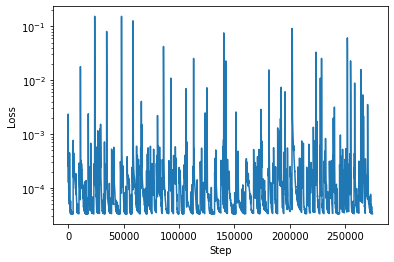

In [25]:
plt.plot([x*100 for x in range(len(lossList))], lossList)
plt.ylabel('Loss')
plt.xlabel('Step')
plt.yscale("log")
plt.show()

## Result

### best parameters

In [26]:
ys = cls_predict(xs, 50, best_params)

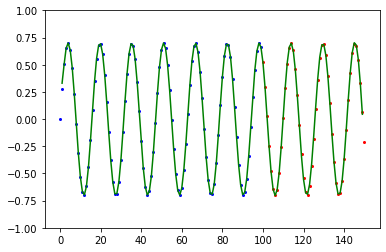

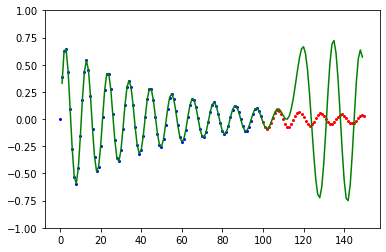

In [27]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

### final parameters

In [28]:
ys = cls_predict(xs, 50, params)

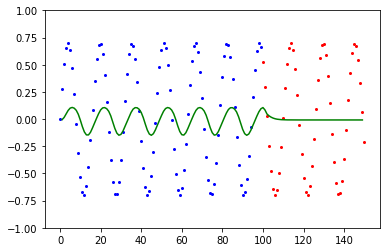

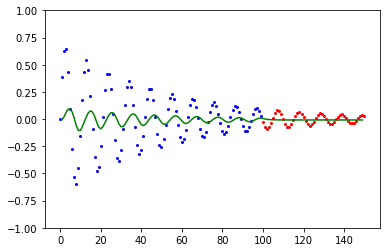

In [29]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

## Load & find the best parameters

In [22]:
# load
# Loss, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_state.pkl', 'rb') as f:
    lossList, minLoss, params, best_params, loc_params_list, reset_steps = pickle.load(f)

In [23]:
test_result = []
min_loss = 1000
k = 0
for i in reset_steps[1:]:
    k += 1
    j = int(i/100 -1)
    i_loss = lossList[j]
    i_params = loc_params_list[k]
    
    ys = cls_predict(xs, 50, i_params)
    
    t_loss = jnp.mean((true2[:,:-1]-ys[:,-50:,0])**2)
    test_result.append([i,i_loss,t_loss,i_params,ys])
    if t_loss < min_loss:
        min_loss = t_loss
        min_idx = k-1
        min_ys = ys
        
test_result[min_idx]

[151500,
 Array(3.30557605e-05, dtype=float64),
 Array(0.00158815, dtype=float64),
 [(Array([[ 0.23068687, -0.51205087,  0.52338583, -0.24847599,  0.57602042,
           -0.27984826,  0.12797267, -0.11379386,  0.6769065 ]],      dtype=float64),
   Array([[ 1.43664242e-01,  4.10923640e-01,  4.54056982e-01,
            6.41878500e-01, -3.86015795e-01,  1.92738376e-01,
            4.50397354e-02, -1.23525348e-01, -1.23517892e-01],
          [ 3.79426202e-01, -2.14768247e-01, -4.00742310e-01,
           -5.69961343e-02,  2.44844192e-01, -5.33096131e-01,
           -3.38849115e-01,  3.70230968e-01, -1.34130952e-01],
          [ 3.32301090e-01,  1.14931078e-01, -3.51975865e-02,
           -1.30540841e-01,  5.62919752e-03, -2.61692091e-01,
           -4.15724014e-02, -6.48639691e-01, -3.23092629e-01],
          [ 1.67639343e-01,  4.79927226e-01,  1.22611955e-01,
           -6.28512084e-01, -2.84114964e-01,  2.45313011e-01,
           -6.81594285e-02,  1.57542331e-01,  1.08916091e-01],
       

In [24]:
# Save results
# [[i,i_loss,t_loss,i_params,ys]...]
with open(nb_name+'_test_result.pkl', 'wb') as f:
    pickle.dump(test_result, f)

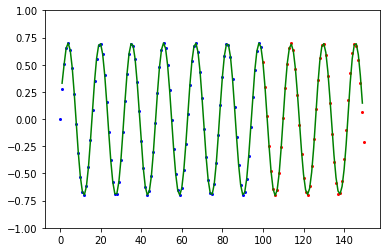

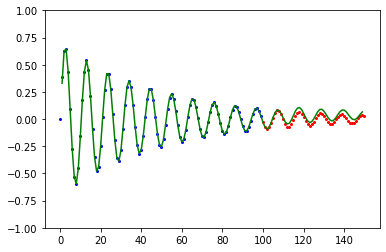

In [32]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(min_ys[idx])))+1, min_ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

best: [151500, Array(3.30557605e-05, dtype=float64), Array(0.00158815, dtype=float64)]
4600 3.3108797703082567e-05 4.658800952128735


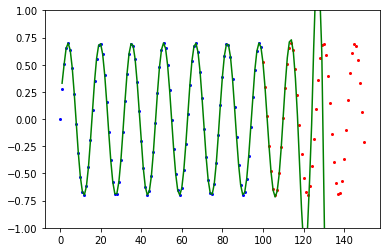

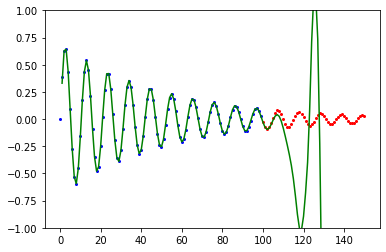

9900 3.331330674337226e-05 0.06016607767011536


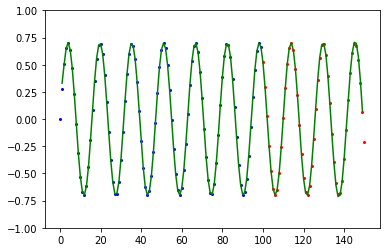

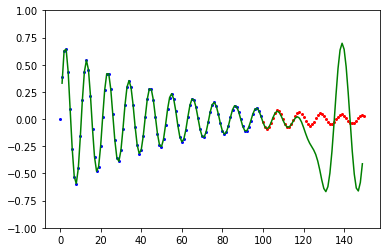

18200 3.310546856238959e-05 0.1043661900222717


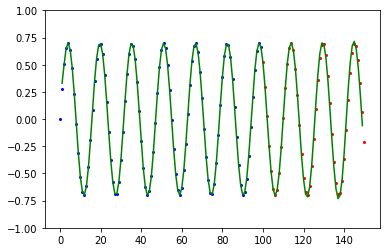

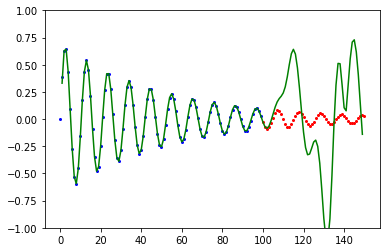

23300 3.3105439854035406e-05 0.0029779308926457648


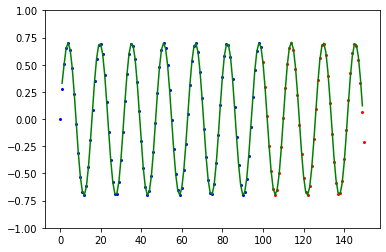

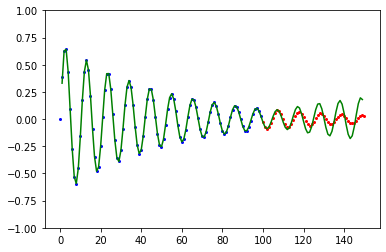

28400 3.361034023850585e-05 0.268327493669648


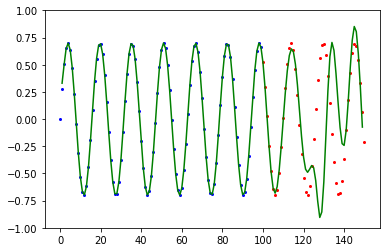

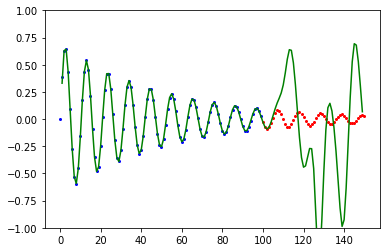

33600 3.33236507802197e-05 0.41146703924396205


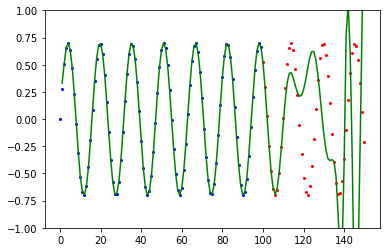

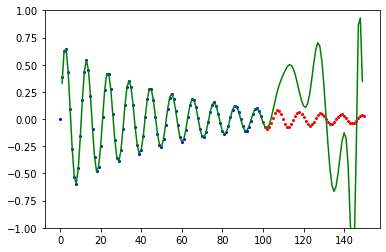

39300 3.338766851331905e-05 0.24991749963350265


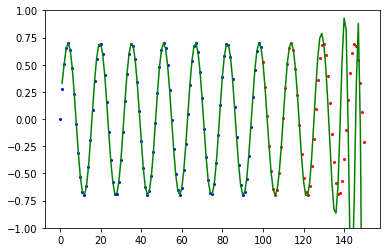

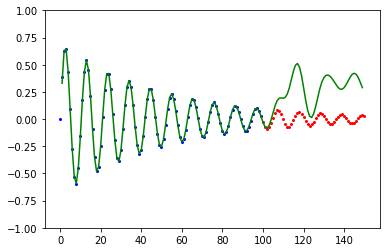

47200 3.311707720725682e-05 0.4635719948236924


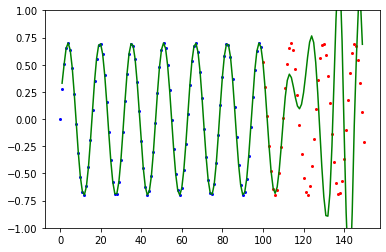

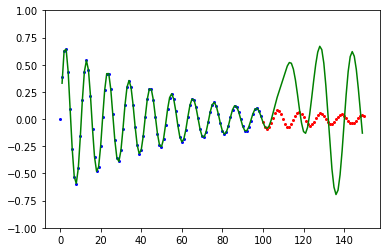

53300 3.302721621471609e-05 0.09234761118195453


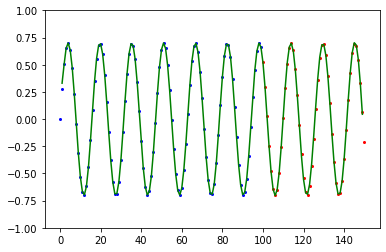

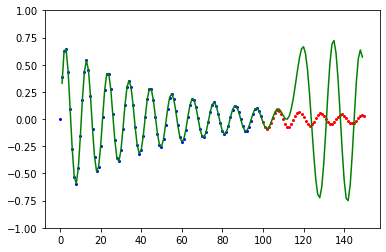

57700 3.3080819852670706e-05 0.0924064152383393


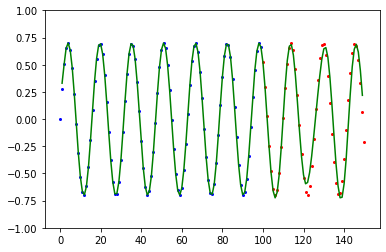

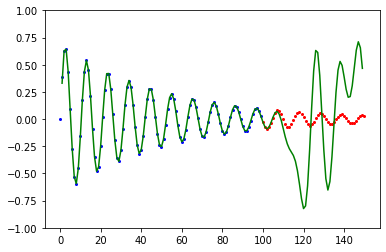

65200 3.312404775839816e-05 0.29678462207842443


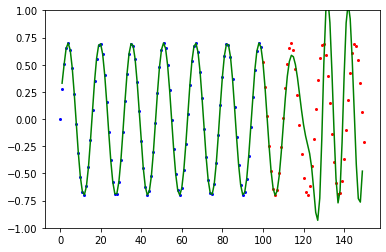

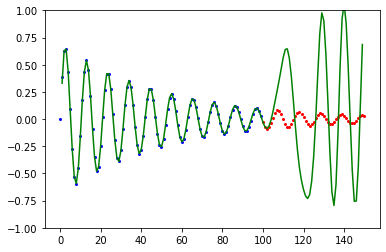

71500 3.316241540305542e-05 0.08316302649984411


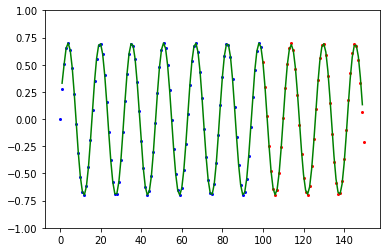

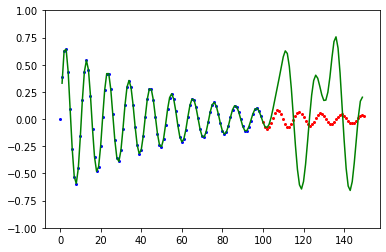

75800 3.3257007493393266e-05 0.015124760822100911


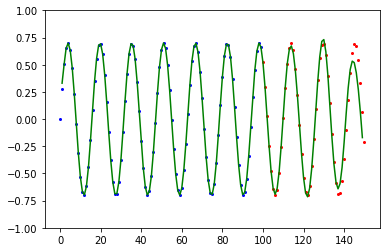

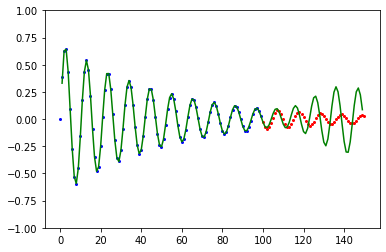

79700 3.485221726252991e-05 0.01446899220627097


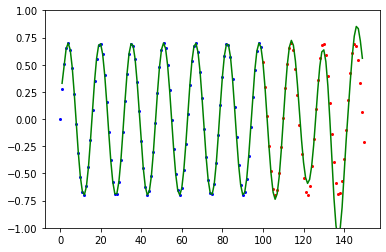

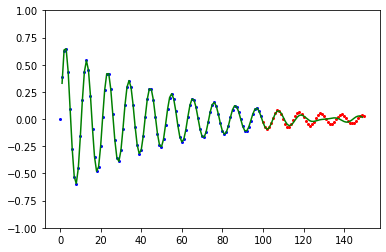

85100 3.3680294786109425e-05 0.006874158882631347


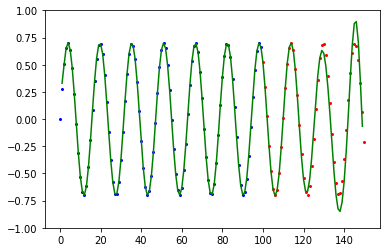

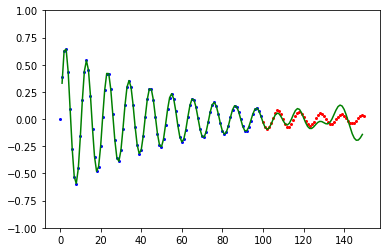

90900 3.34227792385435e-05 5.513755536175289


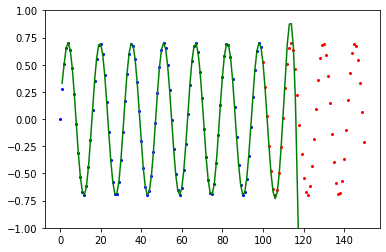

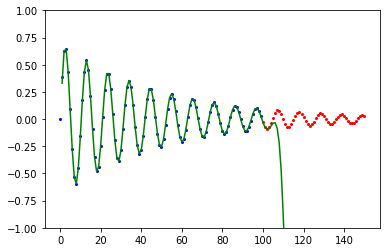

95200 3.3318095647984035e-05 0.08161032068308799


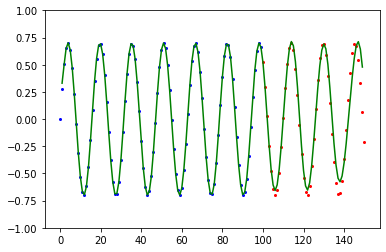

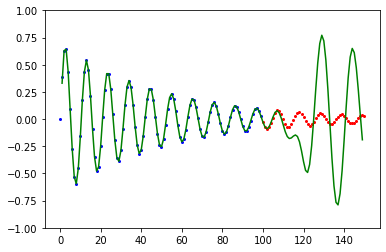

100200 3.315950224122538e-05 0.18240748703563558


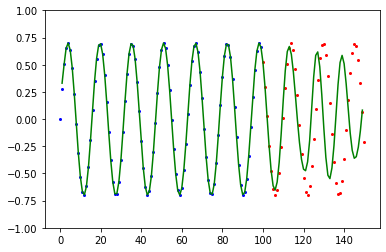

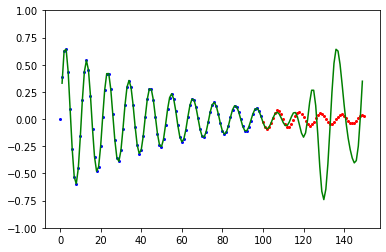

104600 3.31435370101029e-05 0.009461675625695212


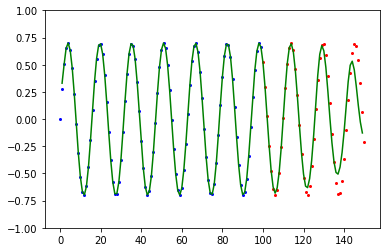

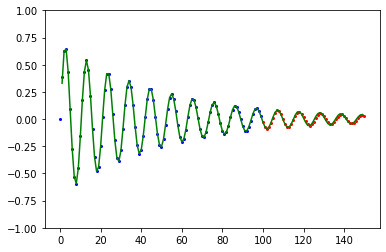

112900 3.3221242702574725e-05 0.04252450889051582


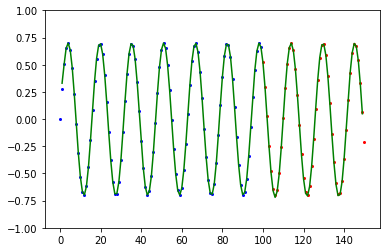

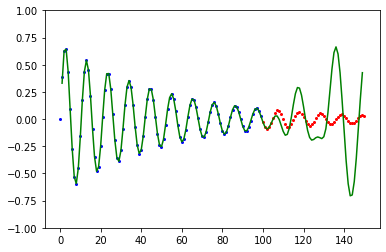

119300 3.318621397918806e-05 4.586921648787753


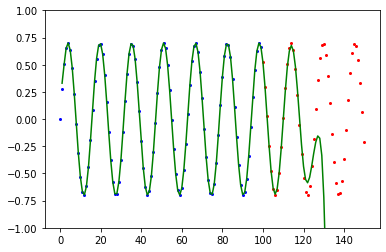

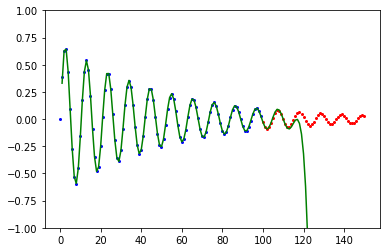

123400 3.3410032152147725e-05 0.030476452910695333


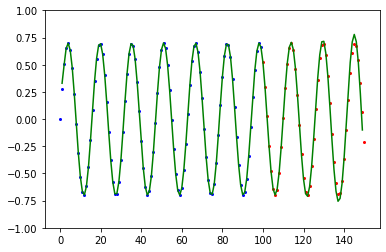

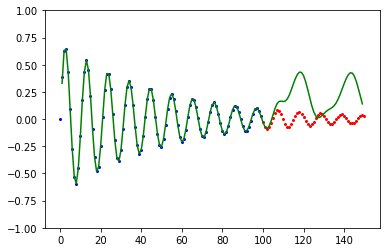

132300 3.315076127930626e-05 0.03816928287786027


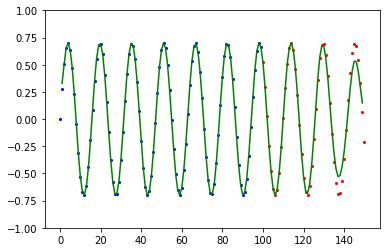

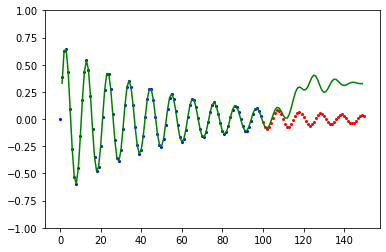

137900 3.4244875687581e-05 1.1986020569801472


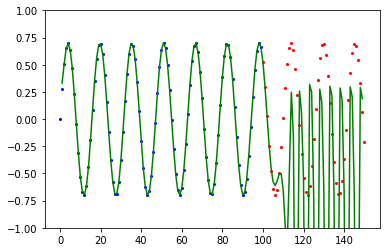

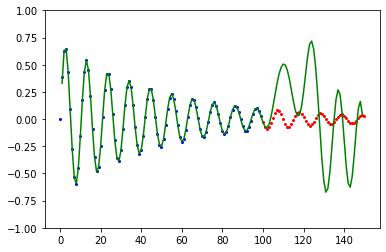

143900 3.3597428839014494e-05 0.1337428876613983


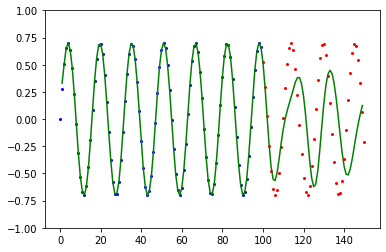

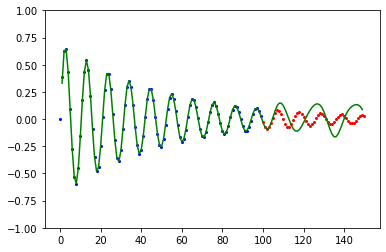

151500 3.3055760526139354e-05 0.0015881547703042156


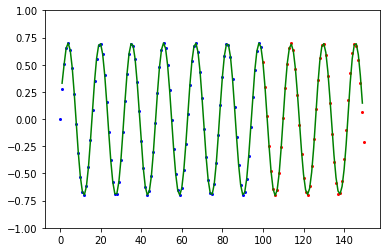

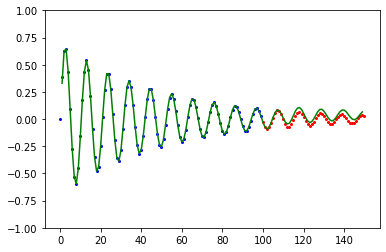

160400 3.331344594119481e-05 0.0033907486359257572


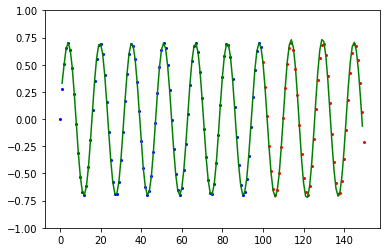

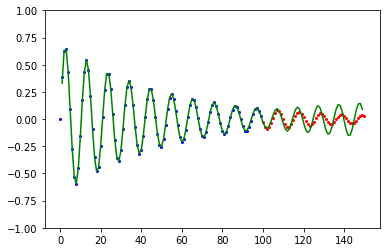

167500 3.386775510937874e-05 0.23698982131040494


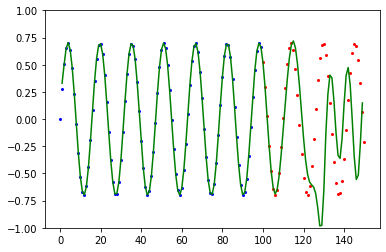

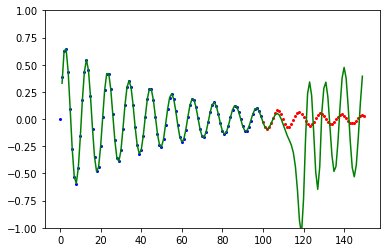

173200 3.320847144205243e-05 0.006348003720374381


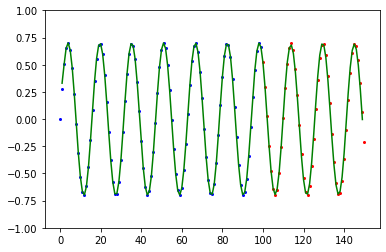

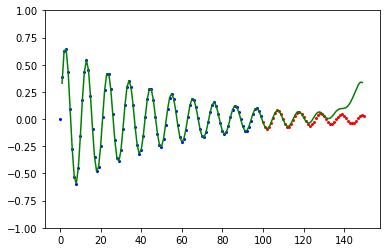

180700 3.3339455368742524e-05 0.78567119043907


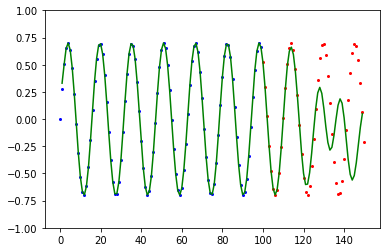

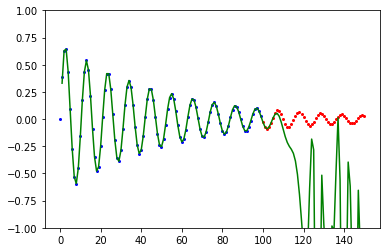

184800 3.360577585620198e-05 0.03508304868844757


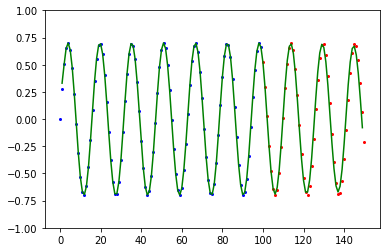

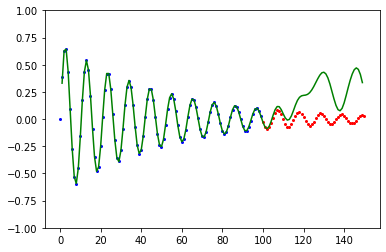

189200 3.3234757374170744e-05 0.02384497525963169


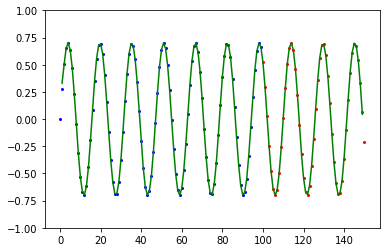

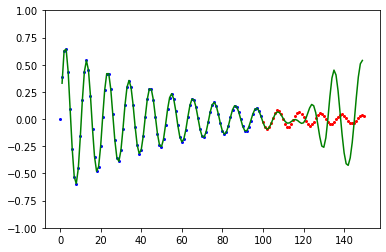

194800 3.352162923808258e-05 4.209345384500023


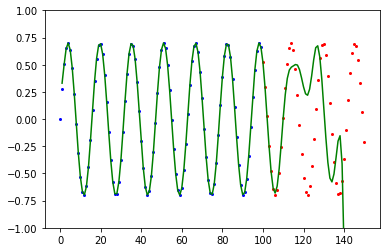

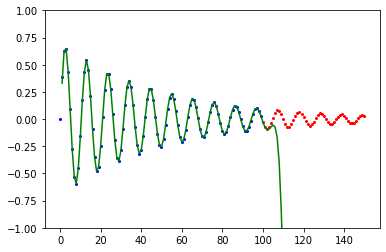

200500 3.6522642128122925e-05 4.065152418766687


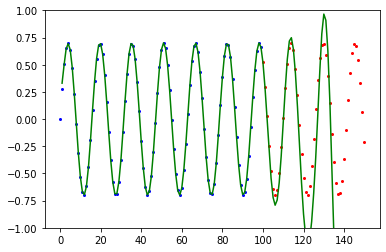

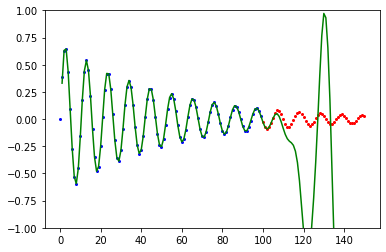

210900 3.5185239424462694e-05 0.03264982948994442


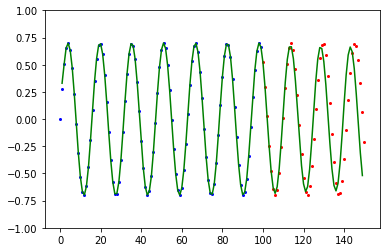

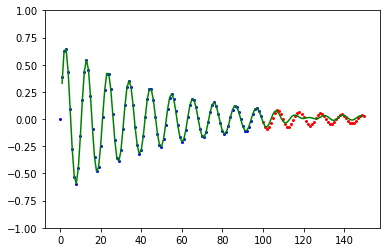

215400 3.32375273549339e-05 0.025441752597868707


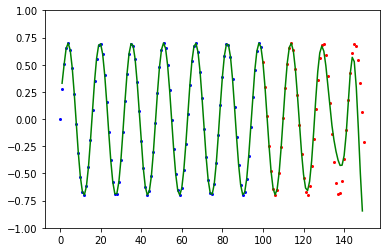

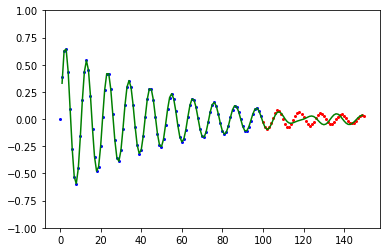

218500 3.4082349881849306e-05 0.11495921132306423


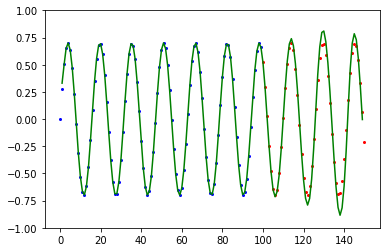

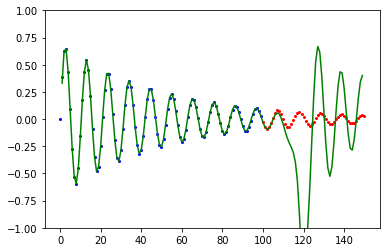

222900 3.531398434474094e-05 0.5183122289964919


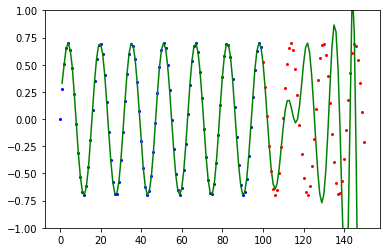

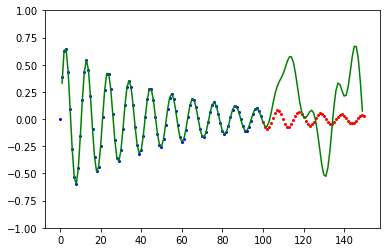

227300 3.31562229161387e-05 0.5458626810788568


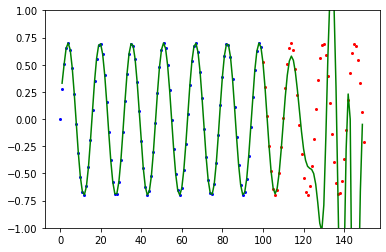

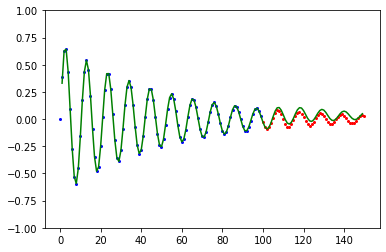

231000 3.3385534007704165e-05 0.10477844160146166


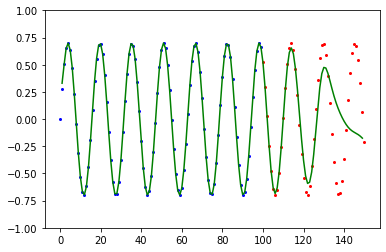

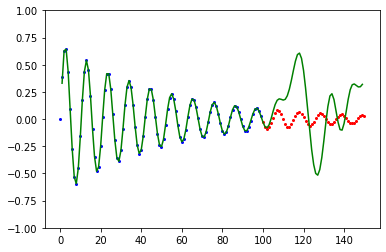

235900 3.3528872425902105e-05 0.1765458462705365


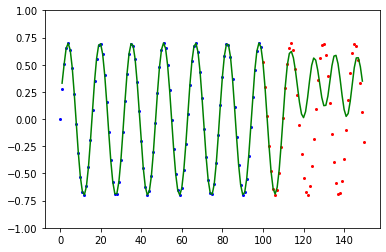

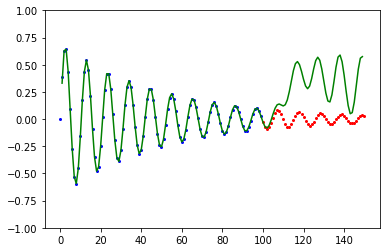

239000 3.3653833718009226e-05 0.17270933468999183


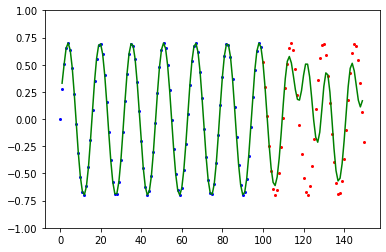

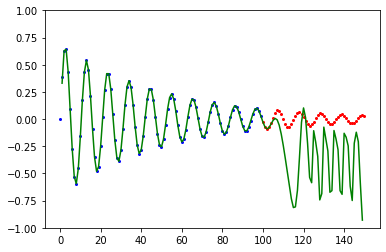

245100 3.319789613196802e-05 0.8145236914066376


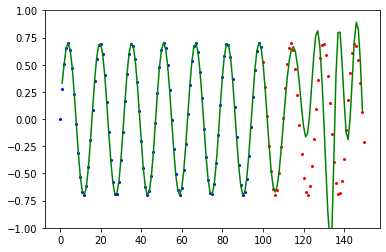

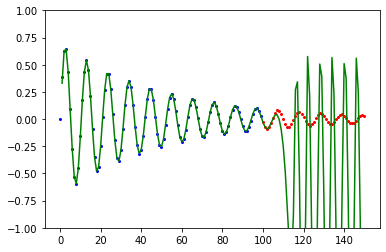

249300 3.451912715900927e-05 0.20196760174111053


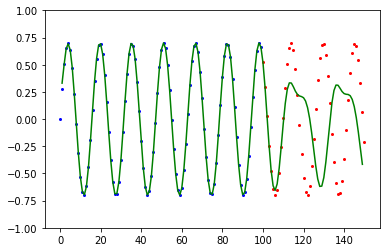

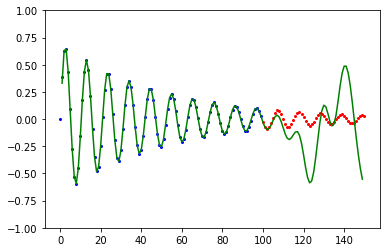

253500 3.6581717222451434e-05 0.6218728237974044


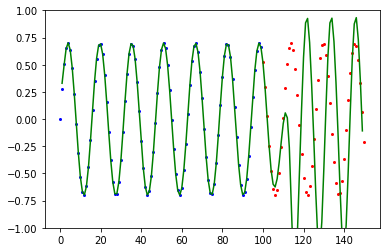

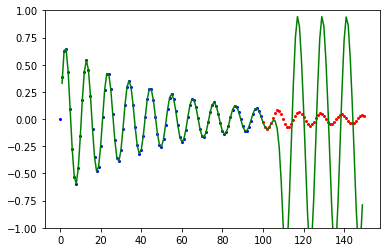

258200 3.3319480837163994e-05 0.3974586223295591


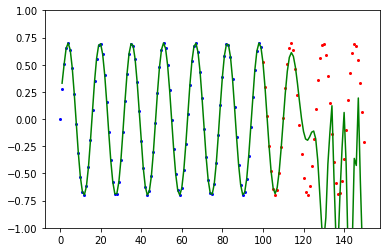

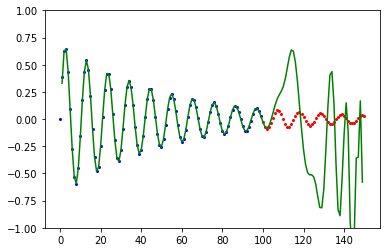

262600 3.39783890174072e-05 0.2754090055019959


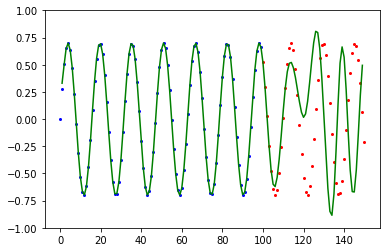

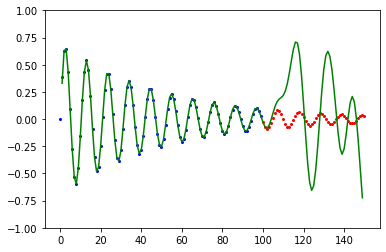

265800 5.272674263983961e-05 0.09020798701231279


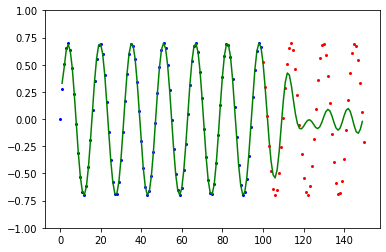

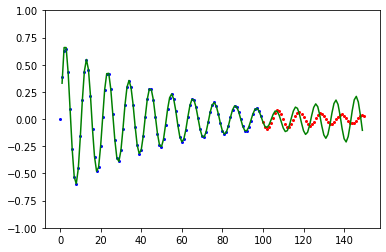

268400 3.385806309403285e-05 0.002460291072394821


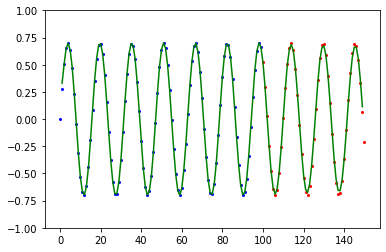

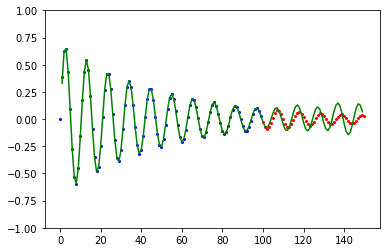

274900 3.329034975325509e-05 1.0264597104807944


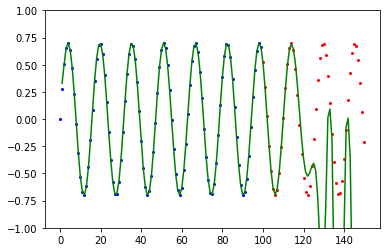

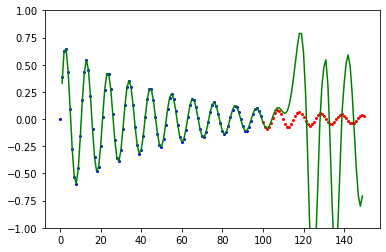

In [33]:
print('best:', test_result[min_idx][0:3])
for pak in test_result:
    i, i_loss, t_loss, _, ys = pak
    print(i, i_loss, t_loss)
    for idx in [0, 1]:
        plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
        plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
        plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
        plt.ylim(-1,1)
        plt.show()

In [34]:
sum([_[2] for _ in test_result])/len(test_result)

Array(0.66254939, dtype=float64)

In [35]:
len(test_result)

50